## Architecture

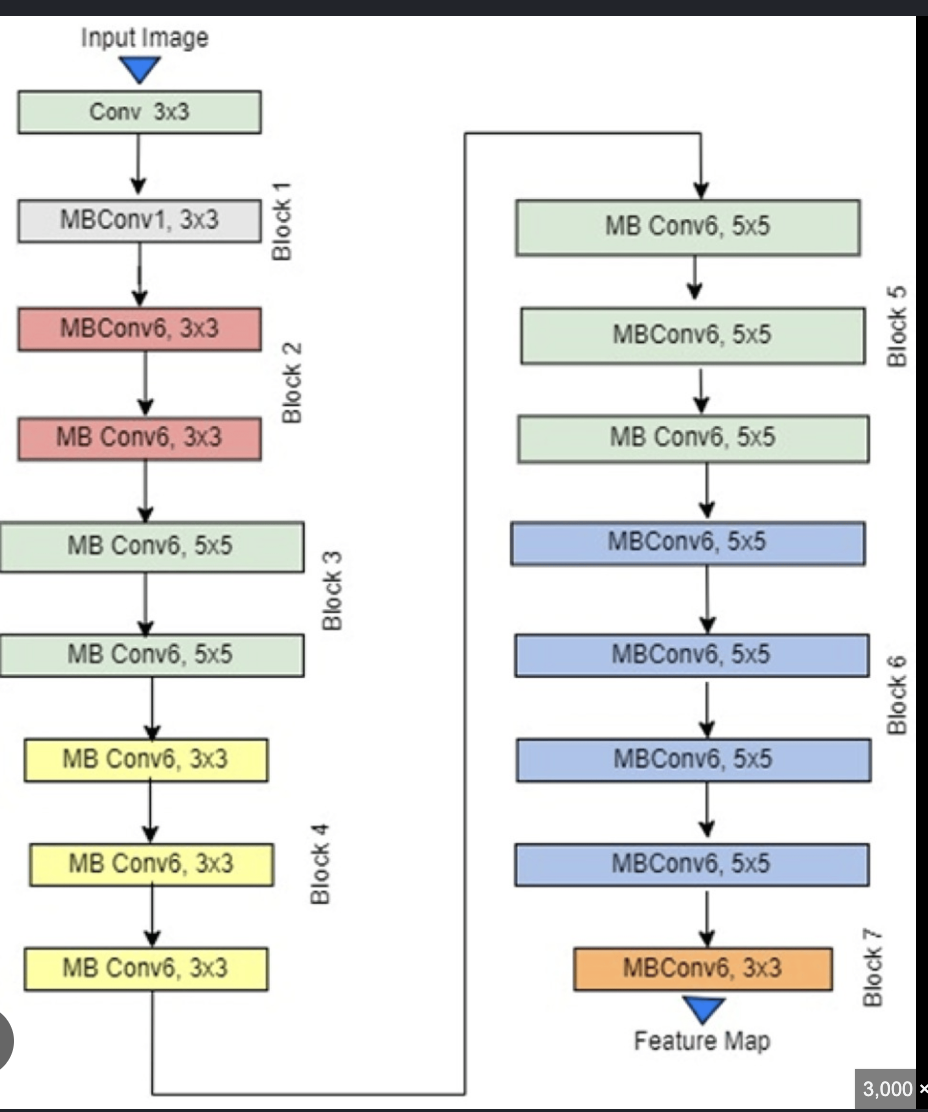

EfficientNet scales all three together:<br>

depth x width x resolution <br>

which gives much better accuracy per parameter.

## WIDER AND DEEPER

In [2]:
import torch
import torch.nn as nn
from torchvision import datasets
from torch.optim import AdamW
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
from torchvision import transforms
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision.transforms import  ToTensor, Compose
from time import time
import matplotlib.pyplot as plt
import seaborn as sns
from ptflops import get_model_complexity_info

In [3]:
from torchvision.models import(efficientnet_b0, EfficientNet_B0_Weights)

model= efficientnet_b0(weights= EfficientNet_B0_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 143MB/s] 


In [4]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [5]:
model.classifier
#fully connected layer

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

## replacing the classifier head


### classifier had 1000 outs but we want only 2

In [6]:
model.classifier=nn.Linear(model.classifier[1].in_features,1)

In [7]:
device=torch.device('cuda')

In [8]:
model=model.to(device)

# Dataset Configure and Normalize and Dataloader

In [9]:
data_dir="/kaggle/input/datasets/parth04pt/cat-dog-images/data"

In [10]:
dataset= ImageFolder(data_dir)

In [11]:
gen = torch.Generator().manual_seed(42)

In [12]:
train_size= int(0.8* len(dataset))
test_size= len(dataset) - train_size

train_subset, test_subset= random_split(dataset, [train_size, test_size], generator=gen)

## DATA AUGMENTATIONS

In [13]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [14]:
test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [15]:
train_dataset = torch.utils.data.Subset(
    ImageFolder(
        root=data_dir,
        transform=train_transform
    ),
    train_subset.indices
)

test_dataset = torch.utils.data.Subset(
    ImageFolder(
        root=data_dir,
        transform=test_transform
    ),
    test_subset.indices
)

In [16]:
train_loader=DataLoader(train_dataset , batch_size=64, shuffle=True)
test_loader=DataLoader(test_dataset, batch_size=64, shuffle=False )

## freeze the back bone and unfreeze the head

In [17]:
# all freezed
for p in model.parameters():
    p.requires_grad=False

#head unfreezed
for p in model.classifier.parameters():
    p.requires_grad= True

In [18]:
loss= nn.BCEWithLogitsLoss()
optim=torch.optim.AdamW(model.classifier.parameters(),lr=1e-3)

In [19]:
classifer_epochs=5

# TRAINING THE CLASSIFIER HEAD TO UNDERSTAND DOG VS CAT

In [20]:
start = time()

for epoch in tqdm(range(classifer_epochs)):

    model.train()

    total = 0
    correct = 0
    epoch_loss = 0.0

    for imgs, labels in train_loader:

        imgs = imgs.to(device)

        labels = (
            labels.float()
            .unsqueeze(1)
            .to(device)
        )

        logits = model(imgs)

        l = loss(
            logits,
            labels
        )

        optim.zero_grad()

        l.backward()

        optim.step()

        probs = torch.sigmoid(logits)

        preds = (
            probs > 0.5
        ).float()

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

        epoch_loss += l.item()
    
    print(
        f"Loss Epoch {epoch+1}: "
        f"{epoch_loss/len(train_loader):.4f}"
    )

    print(
        f"Accuracy Epoch {epoch+1}: "
        f"{100*correct/total:.2f}%"
    )

train_time = time() - start

  0%|          | 0/5 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
 20%|██        | 1/5 [03:29<13:57, 209.29s/it]

Loss Epoch 1: 0.2293
Accuracy Epoch 1: 92.93%


 40%|████      | 2/5 [05:34<07:58, 159.60s/it]

Loss Epoch 2: 0.1322
Accuracy Epoch 2: 95.30%


 60%|██████    | 3/5 [07:38<04:47, 143.73s/it]

Loss Epoch 3: 0.1189
Accuracy Epoch 3: 95.52%


 80%|████████  | 4/5 [09:45<02:17, 137.13s/it]

Loss Epoch 4: 0.1142
Accuracy Epoch 4: 95.45%


100%|██████████| 5/5 [11:51<00:00, 142.28s/it]

Loss Epoch 5: 0.1075
Accuracy Epoch 5: 95.67%


# Unfreeze the entire Network

In [21]:
for p in model.parameters():
    p.requires_grad= True

### new optimizeer for next training and schedular

In [22]:
optimizer = torch.optim.AdamW(model.parameters(),lr=1e-5,weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=10)

# FINE TUNING TRAINING LOOP

In [23]:
FT_EPOCHS=10

In [24]:
start = time()

for epoch in tqdm(range(FT_EPOCHS)):

    model.train()

    total = 0
    correct = 0
    epoch_loss = 0.0

    for imgs, labels in train_loader:

        imgs = imgs.to(device)

        labels = (
            labels.float()
            .unsqueeze(1)
            .to(device)
        )

        logits = model(imgs)

        l = loss(
            logits,
            labels
        )

        optim.zero_grad()

        l.backward()

        optim.step()

        probs = torch.sigmoid(logits)

        preds = (
            probs > 0.5
        ).float()

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

        epoch_loss += l.item()

    print(
        f"Loss Epoch {epoch+1}: "
        f"{epoch_loss/len(train_loader):.4f}"
    )

    print(
        f"Accuracy Epoch {epoch+1}: "
        f"{100*correct/total:.2f}%"
    )

train_time = time() - start

 10%|█         | 1/10 [03:15<29:16, 195.19s/it]

Loss Epoch 1: 0.1031
Accuracy Epoch 1: 95.98%


 20%|██        | 2/10 [06:30<26:03, 195.50s/it]

Loss Epoch 2: 0.1031
Accuracy Epoch 2: 95.96%


 30%|███       | 3/10 [09:46<22:49, 195.61s/it]

...

Loss Epoch 8: 0.0977
Accuracy Epoch 8: 96.06%


 90%|█████████ | 9/10 [29:10<03:14, 194.33s/it]

Loss Epoch 9: 0.0957
Accuracy Epoch 9: 96.18%


100%|██████████| 10/10 [32:23<00:00, 194.33s/it]

Loss Epoch 10: 0.0937
Accuracy Epoch 10: 96.24%


## TESTING

In [25]:
model.eval()

correct = 0
total = 0

LOSS = 0.0

all_preds = []
all_labels = []

start = time()

with torch.no_grad():

    for imgs, labels in test_loader:

        imgs = imgs.to(device)

        labels = (
            labels.float()
            .unsqueeze(1)
            .to(device)
        )

        logits = model(imgs)

        l = loss(
            logits,
            labels
        )

        probs = torch.sigmoid(logits)

        preds = (
            probs > 0.5
        ).float()

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

        LOSS += l.item()

        all_preds.extend(
            preds.cpu().numpy().flatten()
        )

        all_labels.extend(
            labels.cpu().numpy().flatten()
        )

test_time = time() - start

print(
    f"Test Loss : "
    f"{LOSS/len(test_loader):.4f}"
)

print(
    f"Test Accuracy : "
    f"{100*correct/total:.2f}%"
)

print(
    f"Test Time : "
    f"{test_time:.2f}s"
)

Test Loss : 0.0889
Test Accuracy : 96.60%
Test Time : 57.93s


## custom inference
#### file path -> pil image -> tensor -> unsqueeze(0) -> pass to model

In [26]:
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [28]:
from PIL import Image
model.eval()
dog = Image.open("/kaggle/input/datasets/parth04pt/cat-dog-infer-imgs/dog.jpeg").convert("RGB")
cat=Image.open("/kaggle/input/datasets/parth04pt/cat-dog-infer-imgs/cat.png").convert("RGB")

In [29]:
infer_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [30]:
dog_tensor = infer_transform(dog)

cat_tensor = infer_transform(cat)

In [33]:
start= time()
logit1 = model(dog_tensor.unsqueeze(0).to(device))
prob1 = torch.sigmoid(logit1)
prediction1 = int(prob1 > 0.5)
infer_time1 = time()- start

In [34]:
confidence1 = prob1.item()

In [35]:
cls=["cat", "dog"]

In [36]:
mean=[0.485,0.456,0.406]
std_dev=[0.229,0.224,0.225]

In [37]:
mean=torch.tensor(mean)
std_dev=torch.tensor(std_dev)

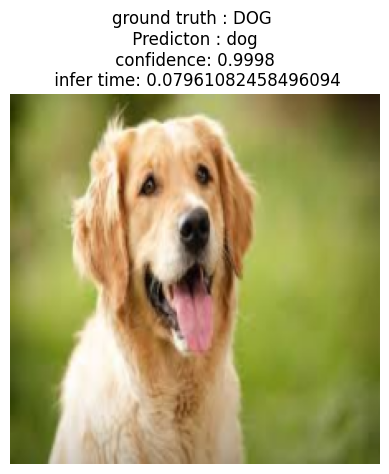

In [38]:
plt.title(f"ground truth : DOG \n Predicton : {cls[prediction1]} \n confidence: {confidence1:.4f} \n infer time: {infer_time1}")
img= dog_tensor.squeeze(0).cpu()
img = img * std_dev.view(3,1,1).cpu() + mean.view(3,1,1).cpu()
img = img.clamp(0,1)
plt.imshow(img.permute(1,2,0))
plt.axis("off")
plt.show()

In [40]:
start= time()
logit2 = model(cat_tensor.unsqueeze(0).to(device))
prob2 = torch.sigmoid(logit2)
prediction2 = int(prob2 > 0.5)
infer_time2 = time()- start

In [43]:
confidence2 = 1-prob2.item()

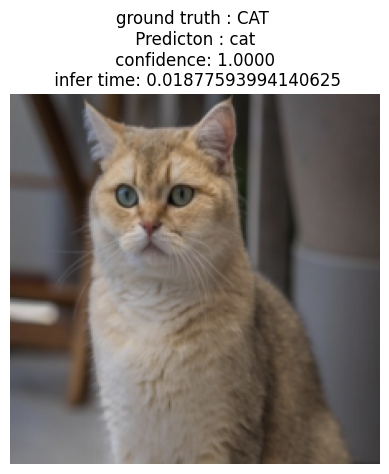

In [44]:
plt.title(f"ground truth : CAT \n Predicton : {cls[prediction2]} \n confidence: {confidence2:.4f} \n infer time: {infer_time2}")
img= cat_tensor.squeeze(0).cpu()
img = img * std_dev.view(3,1,1).cpu() + mean.view(3,1,1).cpu()
img = img.clamp(0,1)
plt.imshow(img.permute(1,2,0))
plt.axis("off")
plt.show()

# METRICS

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

acc= accuracy_score(all_labels, all_preds)
pre = precision_score(all_labels, all_preds),
rec= recall_score(all_labels, all_preds)
f1= f1_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

In [46]:
num_paramerters=0
num_layers=0
for p in model.parameters():
    num_layers+=1
    num_paramerters+=p.numel()
    #weights
    #bias

In [47]:
trainable_parameters = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad

)

In [50]:
memory_usage= torch.torch.cuda.memory_allocated()/1024**2

In [51]:
macs, params = get_model_complexity_info(model,(3,224,224),as_strings=False,print_per_layer_stat=False)

In [52]:
flops= macs*2

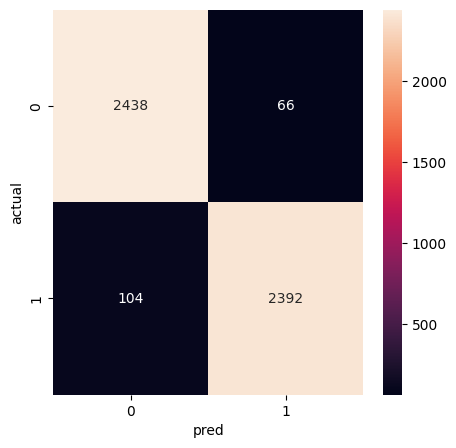

In [53]:
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt= 'd')
plt.xlabel("pred")
plt.ylabel("actual")
plt.show()

In [55]:
print("="*60)
print("EFFICIENTNET-B0 TRANSFER LEARNING RESULTS")
print("="*60)

print(f"Model                : EfficientNet-B0")
print(f"Classifier Epochs    : {classifer_epochs}")
print(f"Fine-Tuning Epochs   : {FT_EPOCHS}")

print()

print(f"Accuracy             : {acc:.4f}")
print(f"Precision            : {pre[0]:.4f}")
print(f"Recall               : {rec:.4f}")
print(f"F1 Score             : {f1:.4f}")

print()

print(f"Training Time        : {train_time:.2f}s")
print(f"Testing Time         : {test_time:.2f}s")

print()

print(f"Parameters           : {num_paramerters:,}")
print(f"Trainable Parameters : {trainable_parameters:,}")
print(f"Layers               : {num_layers:,}")

print()

print(f"FLOPs                : {flops:,.0f}")
print(f"Memory Usage         : {memory_usage:.2f} MB")

print()

print("Classes              :", cls)

print()

print("Confusion Matrix")
print(cm)

print("="*60)

EFFICIENTNET-B0 TRANSFER LEARNING RESULTS
Model                : EfficientNet-B0
Classifier Epochs    : 5
Fine-Tuning Epochs   : 10

Accuracy             : 0.9660
Precision            : 0.9731
Recall               : 0.9583
F1 Score             : 0.9657

Training Time        : 1943.31s
Testing Time         : 57.93s

Parameters           : 4,008,829
Trainable Parameters : 4,008,829
Layers               : 213

FLOPs                : 817,834,354
Memory Usage         : 223.90 MB

Classes              : ['cat', 'dog']

Confusion Matrix
[[2438   66]
 [ 104 2392]]


In [56]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=cls
    )
)

              precision    recall  f1-score   support

         cat       0.96      0.97      0.97      2504
         dog       0.97      0.96      0.97      2496

    accuracy                           0.97      5000
   macro avg       0.97      0.97      0.97      5000
weighted avg       0.97      0.97      0.97      5000

